# 06 — Model Tuning and Final Selection

This notebook tunes the strongest baseline candidates and compares their optimized performance.

Main goals:
- tune shortlisted baseline models
- compare tuned results using cross-validation and test-set metrics
- select the final model for the next stage of the project

In [2]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

import pandas as pd
import numpy as np

from pathlib import Path
import json

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

## 1. Shortlisted models for tuning

Based on the baseline comparison in the previous notebook, the following models were selected for tuning:

- Logistic Regression
- Random Forest
- XGBoost

These models showed the strongest baseline performance and represent different levels of model complexity and interpretability.

## 2. Load the dataset and preprocessing configuration

The raw dataset is loaded again, and the saved preprocessing decisions from earlier notebooks are reused to keep the tuning stage consistent and reproducible.

In [3]:
DATA_PATH = Path("../data/raw/telco.csv")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (7043, 50)


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [4]:
CONFIG_PATH = Path("../reports/feature_config.json")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    feature_config = json.load(f)

feature_config

{'target_column': 'target_churn',
 'dropped_columns': ['Customer Status',
  'Churn Category',
  'Churn Reason',
  'Churn Score',
  'Customer ID',
  'Country',
  'State',
  'City',
  'Zip Code',
  'Latitude',
  'Longitude',
  'Quarter',
  'CLTV',
  'Total Revenue',
  'Under 30',
  'Senior Citizen',
  'Dependents',
  'Referred a Friend',
  'Churn Label'],
 'numeric_features': ['Age',
  'Number of Dependents',
  'Population',
  'Number of Referrals',
  'Tenure in Months',
  'Avg Monthly Long Distance Charges',
  'Avg Monthly GB Download',
  'Monthly Charge',
  'Total Charges',
  'Total Refunds',
  'Total Extra Data Charges',
  'Total Long Distance Charges',
  'Satisfaction Score'],
 'categorical_features': ['Gender',
  'Married',
  'Offer',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Internet Type',
  'Online Security',
  'Online Backup',
  'Device Protection Plan',
  'Premium Tech Support',
  'Streaming TV',
  'Streaming Movies',
  'Streaming Music',
  'Unlimited Data

## 3. Rebuild the modeling dataset

I rebuild the modeling dataset here using the same preprocessing decisions from the earlier notebooks.

The goal is to keep the tuning stage aligned with the baseline modeling stage, so the comparison stays fair and consistent.

In [5]:
df["target_churn"] = df["Churn Label"].map({"No": 0, "Yes": 1})

object_cols = df.select_dtypes(include="object").columns.tolist()
df[object_cols] = df[object_cols].replace("None", np.nan)
df[object_cols] = df[object_cols].replace(r"^\s*$", np.nan, regex=True)

if {"Internet Service", "Internet Type"}.issubset(df.columns):
    no_internet_mask = df["Internet Service"].eq("No") & df["Internet Type"].isna()
    df.loc[no_internet_mask, "Internet Type"] = "No Internet"

if "Internet Type" in df.columns:
    df["Internet Type"] = df["Internet Type"].fillna("Missing")

if "Offer" in df.columns:
    df["Offer"] = df["Offer"].fillna("No Offer")

In [6]:
print(df["Internet Type"].value_counts(dropna=False))
print()
print(df["Offer"].value_counts(dropna=False))

Internet Type
Fiber Optic    3035
DSL            1652
No Internet    1526
Cable           830
Name: count, dtype: int64

Offer
No Offer    3877
Offer B      824
Offer E      805
Offer D      602
Offer A      520
Offer C      415
Name: count, dtype: int64


In [7]:
feature_config["dropped_columns"]

['Customer Status',
 'Churn Category',
 'Churn Reason',
 'Churn Score',
 'Customer ID',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Quarter',
 'CLTV',
 'Total Revenue',
 'Under 30',
 'Senior Citizen',
 'Dependents',
 'Referred a Friend',
 'Churn Label']

In [8]:
drop_cols = feature_config["dropped_columns"]

baseline_df = df.drop(columns=drop_cols).copy()

print("Baseline shape:", baseline_df.shape)
baseline_df.sample(6)

Baseline shape: (7043, 32)


,Gender,Age,Married,Number of Dependents,Population,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Satisfaction Score,target_churn
4315,Female,57,No,0,10155,0,12,Offer D,Yes,36.65,...,One Year,No,Credit Card,19.70,260.90,0.0,0,439.80,4,0
2778,Female,29,No,0,20046,0,43,No Offer,Yes,2.49,...,One Year,No,Credit Card,85.10,3662.25,0.0,30,107.07,3,0
3021,Female,19,Yes,0,46171,10,2,No Offer,Yes,4.65,...,Month-to-Month,No,Bank Withdrawal,90.35,190.50,0.0,0,9.30,3,0
5120,Female,24,Yes,3,25126,9,23,Offer D,Yes,1.88,...,Two Year,Yes,Credit Card,19.65,451.55,0.0,0,43.24,4,0
1892,Female,33,No,0,71678,0,15,No Offer,Yes,9.71,...,Month-to-Month,Yes,Bank Withdrawal,49.10,679.55,0.0,0,145.65,1,1
6323,Female,30,No,0,23141,0,72,Offer A,Yes,35.24,...,Two Year,Yes,Credit Card,112.75,8192.60,0.0,0,2537.28,4,0


## 3.1 Define features and target

The cleaned baseline dataset is separated into input features (`X`) and target labels (`y`) for tuning and final model evaluation.

In [9]:
X = baseline_df.drop(columns=["target_churn"])
y = baseline_df["target_churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 31)
y shape: (7043,)


## 3.2 Restore feature groups

Numeric and categorical feature groups are loaded from the saved preprocessing configuration so that the same pipeline logic can be reused during tuning.

In [10]:
numeric_features = feature_config["numeric_features"]
categorical_features = feature_config["categorical_features"]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 13
Categorical features: 18


## 4. Train-test split

The dataset is divided into training and test sets.

The test set is kept untouched for final tuned-model evaluation, while tuning is performed using cross-validation on the training data.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 31)
X_test : (1409, 31)
y_train: (5634,)
y_test : (1409,)


## 5. Cross-validation setup

Stratified cross-validation is used during tuning to preserve the class distribution of the churn target across folds.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## 6. Rebuild preprocessing pipelines

The same numeric and categorical preprocessing structure from the baseline stage is reused here to ensure consistency between model comparison and tuning.

In [13]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [14]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [15]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Number of Dependents', 'Population',
                                  'Number of Referrals', 'Tenure in Months',
                                  'Avg Monthly Long Distance Charges',
                                  'Avg Monthly GB Download', 'Monthly Charge',
                                  'Total Charges', 'Total Refunds',
                                  'Total Extra Data Charges',
                                  'Total Long Distanc...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Married', 'Offer', 'Phone Service',
                                  'Multiple Lines', 'Internet Service',
                                  'Internet Type', 'Online Security',
                                  'Online Backup', 'Device Protection Plan',
                                  'Premium Tech Support', 'Streaming TV',
                                  'Streaming Movies', 'Streaming Music',
                                  'Unlimited Data', 'Contract',
                                  'Paperless Billing', 'Payment Method'])])

## 7. Tuning strategy

The shortlisted models are tuned using different search strategies based on their complexity.

For **Logistic Regression**, `GridSearchCV` is used because the parameter space is relatively small and can be explored more systematically.

For **Random Forest** and **XGBoost**, `RandomizedSearchCV` is preferred because these models have a larger hyperparameter space, and a focused randomized search is more practical at this stage.

F1-score is used as the main optimization metric because churn prediction requires balancing precision and recall rather than relying on accuracy alone.

## 8. Tune Logistic Regression

Logistic Regression is tuned first because it performed strongly in the baseline comparison and remains one of the most interpretable models in the project.

Its parameter space is relatively small, so a focused grid search can be used to test whether modest adjustments improve the baseline performance.

In [16]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Number of Dependents',
                                                   'Population',
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Charges',
                                                   'Total Refunds',
                                                   'Total E...
                                                  ['Gender', 'Married', 'Offer',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Internet Type',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection Plan',
                                                   'Premium Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Streaming Music',
                                                   'Unlimited Data', 'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

### Logistic Regression tuning choices

A small parameter grid is used to test a few reasonable variations of the baseline model.

The search focuses on:
- `C`, to control the strength of regularization
- `class_weight`, to check whether giving more importance to the minority churn class improves recall and F1-score

This is treated as a focused improvement step rather than a large exhaustive search.

In [17]:
logreg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"]
}

logreg_param_grid

{'classifier__C': [0.01, 0.1, 1, 10],
 'classifier__class_weight': [None, 'balanced']}

### Why GridSearchCV was used here

For Logistic Regression, the parameter space is small enough to evaluate systematically.

Because only a limited number of meaningful combinations are being tested, `GridSearchCV` is appropriate at this stage and keeps the tuning process transparent.

In [18]:
logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

logreg_grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Number '
                                                                          'of '
                                                                          'Dependents',
                                                                          'Population',
                                                                          'Number '
                                                                          'of '
                                                                          'Referrals',
                                                                          'Tenure '
                                                                          'in '
                                                                          'Months',
                                                                          'Avg '
                                                                          'Monthly '
                                                                          '...
                                                                          'Protection '
                                                                          'Plan',
                                                                          'Premium '
                                                                          'Tech '
                                                                          'Support',
                                                                          'Streaming '
                                                                          'TV',
                                                                          'Streaming '
                                                                          'Movies',
                                                                          'Streaming '
                                                                          'Music',
                                                                          'Unlimited '
                                                                          'Data',
                                                                          'Contract',
                                                                          'Paperless '
                                                                          'Billing',
                                                                          'Payment '
                                                                          'Method'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__class_weight': [None, 'balanced']},
             scoring='f1')

In [19]:
logreg_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Number '
                                                                          'of '
                                                                          'Dependents',
                                                                          'Population',
                                                                          'Number '
                                                                          'of '
                                                                          'Referrals',
                                                                          'Tenure '
                                                                          'in '
                                                                          'Months',
                                                                          'Avg '
                                                                          'Monthly '
                                                                          '...
                                                                          'Protection '
                                                                          'Plan',
                                                                          'Premium '
                                                                          'Tech '
                                                                          'Support',
                                                                          'Streaming '
                                                                          'TV',
                                                                          'Streaming '
                                                                          'Movies',
                                                                          'Streaming '
                                                                          'Music',
                                                                          'Unlimited '
                                                                          'Data',
                                                                          'Contract',
                                                                          'Paperless '
                                                                          'Billing',
                                                                          'Payment '
                                                                          'Method'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__class_weight': [None, 'balanced']},
             scoring='f1')

In [20]:
print("Best Parameters:", logreg_grid.best_params_)
print("Best CV F1 Score:", round(logreg_grid.best_score_, 4))

Best Parameters: {'classifier__C': 1, 'classifier__class_weight': None}
Best CV F1 Score: 0.9222


### Evaluate the tuned Logistic Regression model

After cross-validated tuning on the training set, the best Logistic Regression configuration is evaluated on the untouched test set.

In [21]:
best_logreg_model = logreg_grid.best_estimator_

logreg_y_pred = best_logreg_model.predict(X_test)
logreg_y_proba = best_logreg_model.predict_proba(X_test)[:, 1]

logreg_results = {
    "model": "Tuned Logistic Regression",
    "best_cv_f1": logreg_grid.best_score_,
    "test_accuracy": accuracy_score(y_test, logreg_y_pred),
    "test_precision": precision_score(y_test, logreg_y_pred),
    "test_recall": recall_score(y_test, logreg_y_pred),
    "test_f1": f1_score(y_test, logreg_y_pred),
    "test_roc_auc": roc_auc_score(y_test, logreg_y_proba)
}

pd.DataFrame([logreg_results]).round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned Logistic Regression,0.9222,0.9567,0.9484,0.885,0.9156,0.9912


In [22]:
print(classification_report(y_test, logreg_y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1035
           1       0.95      0.89      0.92       374

    accuracy                           0.96      1409
   macro avg       0.95      0.93      0.94      1409
weighted avg       0.96      0.96      0.96      1409



In [23]:
logreg_cm = confusion_matrix(y_test, logreg_y_pred)
logreg_cm

array([[1017,   18],
       [  43,  331]], dtype=int64)

## Interpretation of tuned Logistic Regression

The tuned Logistic Regression model produced results that were extremely close to the baseline version.

Although the tuned configuration slightly changed some test-set metrics, the differences were minimal in practical terms. This suggests that the original baseline Logistic Regression model was already strong, and limited grid tuning did not lead to a meaningful performance gain.

As a result, Logistic Regression remains a stable benchmark, but the tuning stage does not materially change its role in the model comparison.

## 9. Tune Random Forest

Random Forest is tuned next because it achieved the strongest cross-validated baseline performance.

Unlike Logistic Regression, tree-based ensemble models often benefit more noticeably from hyperparameter tuning. For that reason, a focused randomized search is used to test whether Random Forest can improve upon its already strong baseline results.

In [24]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Number of Dependents',
                                                   'Population',
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Charges',
                                                   'Total Refunds',
                                                   'Total E...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married', 'Offer',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Internet Type',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection Plan',
                                                   'Premium Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Streaming Music',
                                                   'Unlimited Data', 'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

### Random Forest tuning choices

A focused hyperparameter space is used to test a few important aspects of the model:

- `n_estimators` controls the number of trees
- `max_depth` controls how deep the trees are allowed to grow
- `min_samples_split` and `min_samples_leaf` help limit overfitting
- `class_weight` checks whether giving more importance to the churn class improves model balance

The goal here is not to search every possible combination, but to test whether reasonable adjustments improve the baseline Random Forest performance.

In [25]:
rf_param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": [None, "balanced"]
}

rf_param_dist

{'classifier__n_estimators': [100, 200, 300],
 'classifier__max_depth': [None, 10, 20, 30],
 'classifier__min_samples_split': [2, 5, 10],
 'classifier__min_samples_leaf': [1, 2, 4],
 'classifier__class_weight': [None, 'balanced']}

### Why RandomizedSearchCV was used here

Random Forest has a wider hyperparameter space than Logistic Regression, so a full grid search would be unnecessarily heavy at this stage.

A randomized search makes it possible to explore a meaningful set of parameter combinations while keeping the tuning process practical.

In [26]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Number '
                                                                                'of '
                                                                                'Dependents',
                                                                                'Population',
                                                                                'Number '
                                                                                'of '
                                                                                'Referrals',
                                                                                'Tenure '
                                                                                'in '
                                                                                'Months',
                                                                                'Avg '
                                                                                'Mon...
                                                                                'Payment '
                                                                                'Method'])])),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'classifier__max_depth': [None, 10, 20,
                                                                  30],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='f1')

In [27]:
rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Number '
                                                                                'of '
                                                                                'Dependents',
                                                                                'Population',
                                                                                'Number '
                                                                                'of '
                                                                                'Referrals',
                                                                                'Tenure '
                                                                                'in '
                                                                                'Months',
                                                                                'Avg '
                                                                                'Mon...
                                                                                'Payment '
                                                                                'Method'])])),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'classifier__max_depth': [None, 10, 20,
                                                                  30],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='f1')

In [28]:
print("Best Parameters:", rf_search.best_params_)
print("Best CV F1 Score:", round(rf_search.best_score_, 4))

Best Parameters: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 20, 'classifier__class_weight': 'balanced'}
Best CV F1 Score: 0.9316


### Evaluate the tuned Random Forest model

After cross-validated tuning on the training set, the best Random Forest configuration is evaluated on the untouched test set.

In [29]:
best_rf_model = rf_search.best_estimator_

rf_y_pred = best_rf_model.predict(X_test)
rf_y_proba = best_rf_model.predict_proba(X_test)[:, 1]

rf_results = {
    "model": "Tuned Random Forest",
    "best_cv_f1": rf_search.best_score_,
    "test_accuracy": accuracy_score(y_test, rf_y_pred),
    "test_precision": precision_score(y_test, rf_y_pred),
    "test_recall": recall_score(y_test, rf_y_pred),
    "test_f1": f1_score(y_test, rf_y_pred),
    "test_roc_auc": roc_auc_score(y_test, rf_y_proba)
}

pd.DataFrame([rf_results]).round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned Random Forest,0.9316,0.961,0.9468,0.9037,0.9248,0.9872


In [30]:
print(classification_report(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1035
           1       0.95      0.90      0.92       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [31]:
rf_cm = confusion_matrix(y_test, rf_y_pred)
rf_cm

array([[1016,   19],
       [  36,  338]], dtype=int64)

## Interpretation of tuned Random Forest

The tuned Random Forest model produced only marginal changes relative to the baseline version.

Its cross-validated F1-score improved slightly, which suggests that the model remained strong during training-time validation. However, this improvement did not translate into a meaningful gain on the held-out test set.

Compared with Logistic Regression, the tuned Random Forest still showed a less balanced final performance. In particular, it maintained very high precision but lower recall for the churn class, meaning that it continued to miss more at-risk customers.

Overall, Random Forest remains a strong candidate from a cross-validation perspective, but its tuned version does not clearly outperform Logistic Regression on the test set. This suggests that the baseline Random Forest was already strong, and the current tuning range did not lead to a substantial practical improvement.

## 10. Tune XGBoost

XGBoost is tuned next because it remained one of the strongest baseline candidates and represents a more advanced boosting-based approach for tabular classification.

Unlike Logistic Regression, XGBoost has a wider hyperparameter space, so a focused randomized search is used to test whether moderate tuning can improve its already strong baseline performance.

In [32]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Number of Dependents',
                                                   'Population',
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Charges',
                                                   'Total Refunds',
                                                   'Total E...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

### XGBoost tuning choices

A focused hyperparameter space is used to test a few important aspects of the model:

- `n_estimators` controls the number of boosting rounds
- `max_depth` controls tree complexity
- `learning_rate` controls how quickly the model learns
- `subsample` reduces overfitting by training on row samples
- `colsample_bytree` reduces overfitting by sampling features per tree

The goal is not to search every possible combination, but to test whether a practical tuning range improves the baseline XGBoost model.

In [33]:
xgb_param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__subsample": [0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_param_dist

{'classifier__n_estimators': [100, 200, 300],
 'classifier__max_depth': [3, 5, 7],
 'classifier__learning_rate': [0.01, 0.05, 0.1],
 'classifier__subsample': [0.8, 0.9, 1.0],
 'classifier__colsample_bytree': [0.8, 0.9, 1.0]}

### Why RandomizedSearchCV was used here

XGBoost has a broader hyperparameter space than Logistic Regression, so a full grid search would be unnecessarily heavy for this stage of the project.

A randomized search provides a practical way to explore meaningful combinations while keeping the workflow manageable.

In [34]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_search

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Number '
                                                                                'of '
                                                                                'Dependents',
                                                                                'Population',
                                                                                'Number '
                                                                                'of '
                                                                                'Referrals',
                                                                                'Tenure '
                                                                                'in '
                                                                                'Months',
                                                                                'Avg '
                                                                                'Mon...
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.8,
                                                                         0.9,
                                                                         1.0],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [3, 5, 7],
                                        'classifier__n_estimators': [100, 200,
                                                                     300],
                                        'classifier__subsample': [0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scoring='f1')

In [35]:
xgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Number '
                                                                                'of '
                                                                                'Dependents',
                                                                                'Population',
                                                                                'Number '
                                                                                'of '
                                                                                'Referrals',
                                                                                'Tenure '
                                                                                'in '
                                                                                'Months',
                                                                                'Avg '
                                                                                'Mon...
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'classifier__colsample_bytree': [0.8,
                                                                         0.9,
                                                                         1.0],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [3, 5, 7],
                                        'classifier__n_estimators': [100, 200,
                                                                     300],
                                        'classifier__subsample': [0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scoring='f1')

In [36]:
print("Best Parameters:", xgb_search.best_params_)
print("Best CV F1 Score:", round(xgb_search.best_score_, 4))

Best Parameters: {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}
Best CV F1 Score: 0.9296


### Evaluate the tuned XGBoost model

After cross-validated tuning on the training set, the best XGBoost configuration is evaluated on the untouched test set.

In [37]:
best_xgb_model = xgb_search.best_estimator_

xgb_y_pred = best_xgb_model.predict(X_test)
xgb_y_proba = best_xgb_model.predict_proba(X_test)[:, 1]

xgb_results = {
    "model": "Tuned XGBoost",
    "best_cv_f1": xgb_search.best_score_,
    "test_accuracy": accuracy_score(y_test, xgb_y_pred),
    "test_precision": precision_score(y_test, xgb_y_pred),
    "test_recall": recall_score(y_test, xgb_y_pred),
    "test_f1": f1_score(y_test, xgb_y_pred),
    "test_roc_auc": roc_auc_score(y_test, xgb_y_proba)
}

pd.DataFrame([xgb_results]).round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Tuned XGBoost,0.9296,0.9631,0.9522,0.9064,0.9288,0.9925


In [38]:
print(classification_report(y_test, xgb_y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1035
           1       0.95      0.91      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [39]:
xgb_cm = confusion_matrix(y_test, xgb_y_pred)
xgb_cm

array([[1018,   17],
       [  35,  339]], dtype=int64)

## Interpretation of tuned XGBoost

The tuned XGBoost model showed the strongest overall test-set performance among the tuned candidates.

It achieved:
- the highest test F1-score
- the highest ROC-AUC
- the highest test accuracy

Its recall for the churn class remained slightly below tuned Logistic Regression, but its overall balance between precision, recall, and ranking performance was stronger.

As a result, tuned XGBoost is selected as the final model candidate, while tuned Logistic Regression remains an important interpretable benchmark.

## 11. Final comparison of tuned models

The tuned shortlisted models are compared side by side to support final model selection.

The comparison focuses on:
- cross-validated F1-score
- test-set recall
- test-set F1-score
- ROC-AUC
- overall balance between churn detection and false alarms

In [40]:
final_tuned_results = pd.DataFrame([
    logreg_results,
    rf_results,
    xgb_results
]).sort_values(by="test_f1", ascending=False)

final_tuned_results.round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
2,Tuned XGBoost,0.9296,0.9631,0.9522,0.9064,0.9288,0.9925
1,Tuned Random Forest,0.9316,0.9610,0.9468,0.9037,0.9248,0.9872
0,Tuned Logistic Regression,0.9222,0.9567,0.9484,0.8850,0.9156,0.9912


## Interpretation of tuned model comparison

The final tuned comparison shows that:

- **Tuned XGBoost** achieved the strongest overall test-set performance.
- **Tuned Logistic Regression** remained highly competitive and provided the strongest interpretability.
- **Tuned Random Forest** remained strong in cross-validation, but did not achieve the best balance on the held-out test set.

This suggests that XGBoost is the strongest final predictive candidate, while Logistic Regression remains an important interpretable benchmark.

In [41]:
expanded_model_name = "XGBoost with Satisfaction Score"
xgb_sensitivity_name = "XGBoost without Satisfaction Score"

## 12. Why I am doing one more conservative check

Up to this point, tuned XGBoost looks like the strongest model in the expanded setup.

Still, I do not want to stop at raw performance alone. `Satisfaction Score` stands out as a very strong feature, and I am not fully comfortable treating it as an ordinary input without checking how much the final results depend on it.

Because of that, I run one more conservative comparison without `Satisfaction Score`.

The goal is not to prove that the feature is definitely leakage. The goal is to see whether the overall model ranking stays reasonably stable once this high-impact feature is removed.

## 13. Build the conservative dataset without `Satisfaction Score`

To make the conservative comparison fair, I first rebuild the modeling setup without `Satisfaction Score`.

This means creating a reduced feature matrix, rebuilding the train/test split for that version, and defining a matching preprocessing pipeline before retuning any models.

In [42]:
X_no_sat = X.drop(columns=["Satisfaction Score"]).copy()

print("Original shape:", X.shape)
print("Without Satisfaction Score:", X_no_sat.shape)

Original shape: (7043, 31)
Without Satisfaction Score: (7043, 30)


In [43]:
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_no_sat,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_ns:", X_train_ns.shape)
print("X_test_ns :", X_test_ns.shape)
print("y_train_ns:", y_train_ns.shape)
print("y_test_ns :", y_test_ns.shape)

X_train_ns: (5634, 30)
X_test_ns : (1409, 30)
y_train_ns: (5634,)
y_test_ns : (1409,)


In [44]:
numeric_features_ns = [col for col in numeric_features if col != "Satisfaction Score"]
categorical_features_ns = categorical_features.copy()

print("Numeric features without Satisfaction Score:", len(numeric_features_ns))
print("Categorical features:", len(categorical_features_ns))
print()
print("Numeric features:")
print(numeric_features_ns)
print()
print("Categorical features:")
print(categorical_features_ns)

Numeric features without Satisfaction Score: 12
Categorical features: 18

Numeric features:
['Age', 'Number of Dependents', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges']

Categorical features:
['Gender', 'Married', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']


In [45]:
preprocessor_ns = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features_ns),
    ("cat", categorical_pipeline, categorical_features_ns)
])

preprocessor_ns

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Number of Dependents', 'Population',
                                  'Number of Referrals', 'Tenure in Months',
                                  'Avg Monthly Long Distance Charges',
                                  'Avg Monthly GB Download', 'Monthly Charge',
                                  'Total Charges', 'Total Refunds',
                                  'Total Extra Data Charges',
                                  'Total Long Distanc...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Married', 'Offer', 'Phone Service',
                                  'Multiple Lines', 'Internet Service',
                                  'Internet Type', 'Online Security',
                                  'Online Backup', 'Device Protection Plan',
                                  'Premium Tech Support', 'Streaming TV',
                                  'Streaming Movies', 'Streaming Music',
                                  'Unlimited Data', 'Contract',
                                  'Paperless Billing', 'Payment Method'])])

## 14. Retune XGBoost without `Satisfaction Score`

Now that the conservative dataset is ready, I retune XGBoost on this reduced feature set.

I do not want to reuse the earlier tuned version here, because that model was optimized while `Satisfaction Score` was still included. If I want this comparison to be fair, the model has to be tuned again under the new setup.

In [46]:
xgb_pipeline_ns = Pipeline(steps=[
    ("preprocessor", preprocessor_ns),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_search_ns = RandomizedSearchCV(
    estimator=xgb_pipeline_ns,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_search_ns.fit(X_train_ns, y_train_ns)

print("Best Parameters:", xgb_search_ns.best_params_)
print("Best CV F1 Score:", round(xgb_search_ns.best_score_, 4))

Best Parameters: {'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.9}
Best CV F1 Score: 0.6997


In [47]:
best_xgb_model_ns = xgb_search_ns.best_estimator_

xgb_y_pred_ns = best_xgb_model_ns.predict(X_test_ns)
xgb_y_proba_ns = best_xgb_model_ns.predict_proba(X_test_ns)[:, 1]

xgb_no_sat_results = {
    "model": "Retuned XGBoost (without Satisfaction Score)",
    "best_cv_f1": xgb_search_ns.best_score_,
    "test_accuracy": accuracy_score(y_test_ns, xgb_y_pred_ns),
    "test_precision": precision_score(y_test_ns, xgb_y_pred_ns),
    "test_recall": recall_score(y_test_ns, xgb_y_pred_ns),
    "test_f1": f1_score(y_test_ns, xgb_y_pred_ns),
    "test_roc_auc": roc_auc_score(y_test_ns, xgb_y_proba_ns)
}

pd.DataFrame([xgb_no_sat_results]).round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Retuned XGBoost (without Satisfaction Score),0.6997,0.8559,0.7647,0.6604,0.7088,0.9119


In [48]:
print(classification_report(y_test_ns, xgb_y_pred_ns))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      1035
           1       0.76      0.66      0.71       374

    accuracy                           0.86      1409
   macro avg       0.82      0.79      0.81      1409
weighted avg       0.85      0.86      0.85      1409



In [49]:
xgb_cm_ns = confusion_matrix(y_test_ns, xgb_y_pred_ns)
xgb_cm_ns

array([[959,  76],
       [127, 247]], dtype=int64)

In [50]:
xgb_sensitivity_comparison = pd.DataFrame([
    {
        "view": "XGBoost with Satisfaction Score",
        "accuracy": xgb_results["test_accuracy"],
        "precision": xgb_results["test_precision"],
        "recall": xgb_results["test_recall"],
        "f1": xgb_results["test_f1"],
        "roc_auc": xgb_results["test_roc_auc"]
    },
    {
        "view": "XGBoost without Satisfaction Score",
        "accuracy": xgb_no_sat_results["test_accuracy"],
        "precision": xgb_no_sat_results["test_precision"],
        "recall": xgb_no_sat_results["test_recall"],
        "f1": xgb_no_sat_results["test_f1"],
        "roc_auc": xgb_no_sat_results["test_roc_auc"]
    }
])

xgb_sensitivity_comparison.round(4)

,view,accuracy,precision,recall,f1,roc_auc
0,XGBoost with Satisfaction Score,0.9631,0.9522,0.9064,0.9288,0.9925
1,XGBoost without Satisfaction Score,0.8559,0.7647,0.6604,0.7088,0.9119


### Interpretation of the XGBoost conservative rerun

This rerun changes the picture quite a lot.

When `Satisfaction Score` is removed, XGBoost loses a large amount of predictive strength. The drop is especially clear in recall, F1-score, and ROC-AUC.

This does not mean the model becomes useless. It means that a large part of its earlier strength was tied to a feature that I do not want to accept too easily without a more careful review.

Because of that, the next step is to check whether Logistic Regression becomes more competitive under the same conservative setup.

## 15. Retune Logistic Regression without `Satisfaction Score`

Now I want to check whether Logistic Regression becomes more competitive once `Satisfaction Score` is removed.

I am not reusing the earlier tuned version here, because that one was optimized under the expanded feature set. To keep the comparison fair, I tune Logistic Regression again on the conservative version of the data.

In [51]:
logreg_pipeline_ns = Pipeline(steps=[
    ("preprocessor", preprocessor_ns),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_grid_ns = GridSearchCV(
    estimator=logreg_pipeline_ns,
    param_grid=logreg_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

logreg_grid_ns.fit(X_train_ns, y_train_ns)

print("Best Parameters:", logreg_grid_ns.best_params_)
print("Best CV F1 Score:", round(logreg_grid_ns.best_score_, 4))

Best Parameters: {'classifier__C': 10, 'classifier__class_weight': None}
Best CV F1 Score: 0.6897


In [52]:
best_logreg_model_ns = logreg_grid_ns.best_estimator_

logreg_y_pred_ns = best_logreg_model_ns.predict(X_test_ns)
logreg_y_proba_ns = best_logreg_model_ns.predict_proba(X_test_ns)[:, 1]

logreg_no_sat_results = {
    "model": "Retuned Logistic Regression (without Satisfaction Score)",
    "best_cv_f1": logreg_grid_ns.best_score_,
    "test_accuracy": accuracy_score(y_test_ns, logreg_y_pred_ns),
    "test_precision": precision_score(y_test_ns, logreg_y_pred_ns),
    "test_recall": recall_score(y_test_ns, logreg_y_pred_ns),
    "test_f1": f1_score(y_test_ns, logreg_y_pred_ns),
    "test_roc_auc": roc_auc_score(y_test_ns, logreg_y_proba_ns)
}

pd.DataFrame([logreg_no_sat_results]).round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Retuned Logistic Regression (without Satisfact...,0.6897,0.8446,0.7286,0.6604,0.6928,0.9024


In [53]:
print(classification_report(y_test_ns, logreg_y_pred_ns))

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      1035
           1       0.73      0.66      0.69       374

    accuracy                           0.84      1409
   macro avg       0.80      0.79      0.79      1409
weighted avg       0.84      0.84      0.84      1409



In [54]:
logreg_cm_ns = confusion_matrix(y_test_ns, logreg_y_pred_ns)
logreg_cm_ns

array([[943,  92],
       [127, 247]], dtype=int64)

### Interpretation of the conservative Logistic Regression rerun

Once `Satisfaction Score` is removed, Logistic Regression also loses a noticeable amount of predictive strength.

Compared with the conservative XGBoost rerun, it remains close, but it does not move ahead. At this point, the main value of Logistic Regression is still interpretability rather than clearly stronger predictive performance.

To complete the conservative comparison fairly, I still need to retune Random Forest under the same reduced setup before making the final decision.

## 16. Retune Random Forest without `Satisfaction Score`

To finish the conservative comparison, I now retune Random Forest on the same reduced feature set.

I do not want to reuse the earlier tuned version here, because that model was optimized while `Satisfaction Score` was still included. The conservative version should be tuned under its own setup before I compare all three models side by side.

In [55]:
rf_pipeline_ns = Pipeline(steps=[
    ("preprocessor", preprocessor_ns),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_search_ns = RandomizedSearchCV(
    estimator=rf_pipeline_ns,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search_ns.fit(X_train_ns, y_train_ns)

print("Best Parameters:", rf_search_ns.best_params_)
print("Best CV F1 Score:", round(rf_search_ns.best_score_, 4))

Best Parameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 20, 'classifier__class_weight': 'balanced'}
Best CV F1 Score: 0.7005


In [56]:
best_rf_model_ns = rf_search_ns.best_estimator_

rf_y_pred_ns = best_rf_model_ns.predict(X_test_ns)
rf_y_proba_ns = best_rf_model_ns.predict_proba(X_test_ns)[:, 1]

rf_no_sat_results = {
    "model": "Retuned Random Forest (without Satisfaction Score)",
    "best_cv_f1": rf_search_ns.best_score_,
    "test_accuracy": accuracy_score(y_test_ns, rf_y_pred_ns),
    "test_precision": precision_score(y_test_ns, rf_y_pred_ns),
    "test_recall": recall_score(y_test_ns, rf_y_pred_ns),
    "test_f1": f1_score(y_test_ns, rf_y_pred_ns),
    "test_roc_auc": roc_auc_score(y_test_ns, rf_y_proba_ns)
}

pd.DataFrame([rf_no_sat_results]).round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Retuned Random Forest (without Satisfaction Sc...,0.7005,0.8311,0.6635,0.738,0.6987,0.9


In [57]:
print(classification_report(y_test_ns, rf_y_pred_ns))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88      1035
           1       0.66      0.74      0.70       374

    accuracy                           0.83      1409
   macro avg       0.78      0.80      0.79      1409
weighted avg       0.84      0.83      0.83      1409



In [58]:
rf_cm_ns = confusion_matrix(y_test_ns, rf_y_pred_ns)
rf_cm_ns

array([[895, 140],
       [ 98, 276]], dtype=int64)

In [59]:
conservative_model_comparison = pd.DataFrame([
    logreg_no_sat_results,
    rf_no_sat_results,
    xgb_no_sat_results
]).sort_values(by="test_f1", ascending=False)

conservative_model_comparison.round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
2,Retuned XGBoost (without Satisfaction Score),0.6997,0.8559,0.7647,0.6604,0.7088,0.9119
1,Retuned Random Forest (without Satisfaction Sc...,0.7005,0.8311,0.6635,0.7380,0.6987,0.9000
0,Retuned Logistic Regression (without Satisfact...,0.6897,0.8446,0.7286,0.6604,0.6928,0.9024


## 17. Final conservative interpretation and model selection

After removing `Satisfaction Score`, all models became weaker. This confirms that the feature had a strong effect on the earlier results.

XGBoost still gave the highest F1-score and ROC-AUC, while Random Forest produced the highest recall. But once this feature was removed, the gap between the models became much smaller.

At this stage, I do not want to base the final recommendation on predictive performance alone. I also want the final model to be easier to explain, easier to defend, and simpler to use in practice.

Because of that, I keep Logistic Regression as the final conservative recommendation. It is not the strongest model on every metric, but it gives a more interpretable and easier-to-defend result, which makes it a better fit for a cautious business-facing conclusion.

So, by the end of this notebook, I keep two final reference points:

- **Expanded high-performance model:** XGBoost with `Satisfaction Score`
- **Recommended conservative model:** Logistic Regression without `Satisfaction Score`

In [60]:
print("Conservative final model: Logistic Regression without Satisfaction Score\n")
print(classification_report(y_test_ns, logreg_y_pred_ns))
confusion_matrix(y_test_ns, logreg_y_pred_ns)

Conservative final model: Logistic Regression without Satisfaction Score

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      1035
           1       0.73      0.66      0.69       374

    accuracy                           0.84      1409
   macro avg       0.80      0.79      0.79      1409
weighted avg       0.84      0.84      0.84      1409



array([[943,  92],
       [127, 247]], dtype=int64)

## 18. Visual comparison of final model views

At this point, I want to compare the two final model views more clearly:

- the expanded high-performance model
- the conservative recommended model

The goal here is not to repeat the full tuning results. It is to show the practical difference between raw predictive strength and the more cautious final recommendation.

### 18.1 ROC curve comparison

The ROC curves show that the expanded model achieves much stronger class separation.

At the same time, the conservative Logistic Regression curve gives a more realistic view of performance under a stricter feature setup. This helps separate raw predictive strength from the final business-facing recommendation.

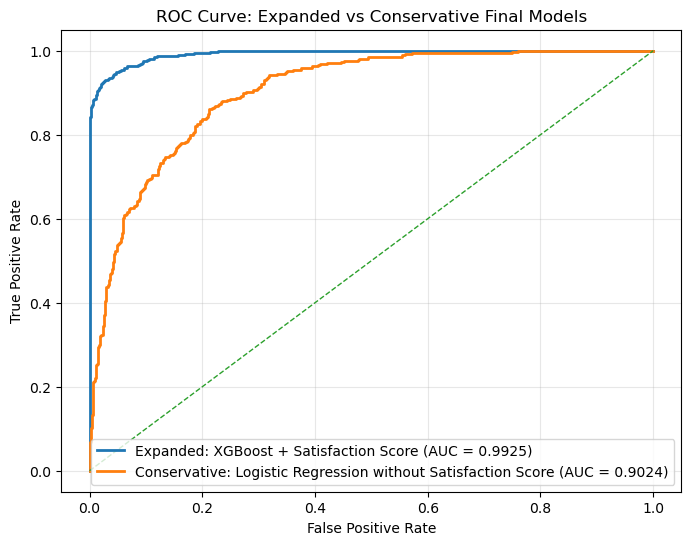

In [61]:
# Expanded final model
fpr_exp, tpr_exp, _ = roc_curve(y_test, xgb_y_proba)
roc_auc_exp = auc(fpr_exp, tpr_exp)

# Conservative final model
fpr_cons, tpr_cons, _ = roc_curve(y_test_ns, logreg_y_proba_ns)
roc_auc_cons = auc(fpr_cons, tpr_cons)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_exp,
    tpr_exp,
    linewidth=2,
    label=f"Expanded: XGBoost + Satisfaction Score (AUC = {roc_auc_exp:.4f})"
)

plt.plot(
    fpr_cons,
    tpr_cons,
    linewidth=2,
    label=f"Conservative: Logistic Regression without Satisfaction Score (AUC = {roc_auc_cons:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Expanded vs Conservative Final Models")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### 18.2 Metric comparison between final model views

This comparison shows how much performance changes when moving from the expanded high-performance model to the conservative recommended model.

The goal is to make the trade-off visible across the main evaluation metrics instead of focusing on a single score.

In [62]:
comparison_plot_df = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Expanded Model": [
        xgb_results["test_accuracy"],
        xgb_results["test_precision"],
        xgb_results["test_recall"],
        xgb_results["test_f1"],
        xgb_results["test_roc_auc"]
    ],
    "Conservative Model": [
        logreg_no_sat_results["test_accuracy"],
        logreg_no_sat_results["test_precision"],
        logreg_no_sat_results["test_recall"],
        logreg_no_sat_results["test_f1"],
        logreg_no_sat_results["test_roc_auc"]
    ]
})

comparison_plot_df

,metric,Expanded Model,Conservative Model
0,Accuracy,0.963094,0.844571
1,Precision,0.952247,0.728614
2,Recall,0.906417,0.660428
3,F1-score,0.928767,0.692847
4,ROC-AUC,0.992462,0.902436


The metric comparison shows a clear drop in performance when moving from the expanded XGBoost model to the conservative Logistic Regression model.

This drop is expected, because the expanded version benefits heavily from `Satisfaction Score`. Even so, the conservative model is still preferred for the final recommendation because it is easier to interpret and easier to defend.

## 19. Final interpretation and recommendation

This project showed me that the strongest model is not always the best final choice.

The expanded XGBoost model gave the highest performance, but this result depended heavily on `Satisfaction Score`. Because this feature may be very close to the churn decision, I treated this model as a comparison point rather than the final recommendation.

For the final reporting, I recommend **Logistic Regression without `Satisfaction Score`**.

Its performance is lower, but the result is easier to understand, explain, and defend. In a business context, this makes the model more reliable as a final recommendation.

## 20. Save final model pipelines

The final step is to save the selected model pipelines so they can be reused later in the Streamlit application.

Two model versions are saved:

- expanded XGBoost model with `Satisfaction Score`
- conservative Logistic Regression model without `Satisfaction Score`

The conservative Logistic Regression model is treated as the main business-facing recommendation.

In [63]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_xgb_model, models_dir / "expanded_xgboost_pipeline.joblib")
joblib.dump(best_logreg_model_ns, models_dir / "conservative_logistic_regression_pipeline.joblib")

['..\\models\\conservative_logistic_regression_pipeline.joblib']

In [64]:
saved_model_files = list(models_dir.glob("*.joblib"))
saved_model_files

[WindowsPath('../models/conservative_logistic_regression_pipeline.joblib'),
 WindowsPath('../models/expanded_xgboost_pipeline.joblib')]

## 21. Conservative Logistic Regression v2 without `Total Charges`

In the conservative final model, `Satisfaction Score` was already removed because of leakage sensitivity.

As an additional interpretability improvement, `Total Charges` is also removed in this version. This is because `Total Charges` is strongly related to `Tenure in Months` and `Monthly Charge`, which can make Logistic Regression coefficients harder to interpret.

This version keeps the model more defensible for business-facing explanation.

In [69]:
X_conservative_v2 = X.drop(columns=["Satisfaction Score", "Total Charges"]).copy()

print("Original shape:", X.shape)
print("Conservative v2 shape:", X_conservative_v2.shape)

Original shape: (7043, 31)
Conservative v2 shape: (7043, 29)


In [70]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_conservative_v2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_v2:", X_train_v2.shape)
print("X_test_v2 :", X_test_v2.shape)

X_train_v2: (5634, 29)
X_test_v2 : (1409, 29)


In [71]:
numeric_features_v2 = [
    col for col in numeric_features
    if col not in ["Satisfaction Score", "Total Charges"]
]

categorical_features_v2 = categorical_features.copy()

print("Numeric features v2:", len(numeric_features_v2))
print("Categorical features v2:", len(categorical_features_v2))
print()
print(numeric_features_v2)

Numeric features v2: 11
Categorical features v2: 18

['Age', 'Number of Dependents', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges']


In [72]:
preprocessor_v2 = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features_v2),
    ("cat", categorical_pipeline, categorical_features_v2)
])

preprocessor_v2

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Number of Dependents', 'Population',
                                  'Number of Referrals', 'Tenure in Months',
                                  'Avg Monthly Long Distance Charges',
                                  'Avg Monthly GB Download', 'Monthly Charge',
                                  'Total Refunds', 'Total Extra Data Charges',
                                  'Total Long Distance Charges']),
                                ('c...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Married', 'Offer', 'Phone Service',
                                  'Multiple Lines', 'Internet Service',
                                  'Internet Type', 'Online Security',
                                  'Online Backup', 'Device Protection Plan',
                                  'Premium Tech Support', 'Streaming TV',
                                  'Streaming Movies', 'Streaming Music',
                                  'Unlimited Data', 'Contract',
                                  'Paperless Billing', 'Payment Method'])])

In [73]:
logreg_pipeline_v2 = Pipeline(steps=[
    ("preprocessor", preprocessor_v2),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_grid_v2 = GridSearchCV(
    estimator=logreg_pipeline_v2,
    param_grid=logreg_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

logreg_grid_v2.fit(X_train_v2, y_train_v2)

print("Best Parameters:", logreg_grid_v2.best_params_)
print("Best CV F1 Score:", round(logreg_grid_v2.best_score_, 4))

Best Parameters: {'classifier__C': 10, 'classifier__class_weight': None}
Best CV F1 Score: 0.6914


In [76]:
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

y_proba_v2 = best_logreg_model_v2.predict_proba(X_test_v2)[:, 1]

thresholds = np.arange(0.20, 0.81, 0.01)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_v2 >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test_v2, y_pred_threshold),
        "recall": recall_score(y_test_v2, y_pred_threshold),
        "f1": f1_score(y_test_v2, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.sort_values(by="f1", ascending=False).head(10)

,threshold,precision,recall,f1
10,0.30,0.601905,0.844920,0.703003
9,0.29,0.595903,0.855615,0.702525
8,0.28,0.593002,0.860963,0.702290
20,0.40,0.660377,0.748663,0.701754
11,0.31,0.607843,0.828877,0.701357
18,0.38,0.652074,0.756684,0.700495
19,0.39,0.655012,0.751337,0.699875
21,0.41,0.667476,0.735294,0.699746
27,0.47,0.708791,0.689840,0.699187
16,0.36,0.634573,0.775401,0.697954


### Threshold selection logic

After testing different probability thresholds, the best F1 score was achieved at a threshold of **0.30**.

This threshold was selected because churn prediction is not only a technical classification problem. It is also a business decision problem.

Different thresholds create different business strategies:

| Business goal | Threshold | Precision | Recall | Interpretation |
|---|---:|---:|---:|---|
| Balanced retention strategy | 0.30 | 0.6019 | 0.8449 | Best F1 score and the strongest overall balance |
| Catch more potential churners | 0.28 | 0.5930 | 0.8610 | Higher recall, but more false positives |
| Protect campaign budget | 0.47 | 0.7088 | 0.6898 | Higher precision, but more churners may be missed |

For this project, the final threshold is set to **0.30**.

The reason is that this threshold gives the best F1 score while still keeping recall high. In a churn prevention context, missing too many real churn customers can be costly. At the same time, precision should not be ignored because retention campaigns also have a cost.

Therefore, threshold **0.30** gives the most reasonable balance between identifying at-risk customers and avoiding unnecessary campaign spending.

In [77]:
best_logreg_model_v2 = logreg_grid_v2.best_estimator_

logreg_y_pred_v2 = best_logreg_model_v2.predict(X_test_v2)
logreg_y_proba_v2 = best_logreg_model_v2.predict_proba(X_test_v2)[:, 1]

logreg_v2_results = {
    "model": "Logistic Regression v2 without Satisfaction Score and Total Charges",
    "best_cv_f1": logreg_grid_v2.best_score_,
    "test_accuracy": accuracy_score(y_test_v2, logreg_y_pred_v2),
    "test_precision": precision_score(y_test_v2, logreg_y_pred_v2),
    "test_recall": recall_score(y_test_v2, logreg_y_pred_v2),
    "test_f1": f1_score(y_test_v2, logreg_y_pred_v2),
    "test_roc_auc": roc_auc_score(y_test_v2, logreg_y_proba_v2)
}

pd.DataFrame([logreg_v2_results]).round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Logistic Regression v2 without Satisfaction Sc...,0.6914,0.8417,0.7254,0.6497,0.6855,0.9016


In [78]:
v1_vs_v2_comparison = pd.DataFrame([
    logreg_no_sat_results,
    logreg_v2_results
])

v1_vs_v2_comparison.round(4)

,model,best_cv_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Retuned Logistic Regression (without Satisfact...,0.6897,0.8446,0.7286,0.6604,0.6928,0.9024
1,Logistic Regression v2 without Satisfaction Sc...,0.6914,0.8417,0.7254,0.6497,0.6855,0.9016


### Final threshold decision

The final Logistic Regression v2 model will use:

- probability threshold: **0.30**
- optimization logic: **best F1 score**
- business focus: **balanced retention strategy**

This means a customer is classified as likely to churn when the predicted churn probability is greater than or equal to **30%**.

In [79]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    best_logreg_model_v2,
    models_dir / "conservative_logistic_regression_v2_pipeline.joblib"
)

['..\\models\\conservative_logistic_regression_v2_pipeline.joblib']